# Multimodal Song Compatibility (MAEST + Chroma + DEAM)

This notebook computes a next-track compatibility distribution from a seed song using three embeddings:
- MAEST embedding similarity
- Chroma embedding similarity
- DEAM valence/arousal similarity

Seed track in this run: **#10 - Illusion** from `music/aries-mix/aries_mix_tracks.csv`.


In [3]:
from __future__ import annotations

import csv
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / "music").exists() and (PROJECT_ROOT.parent / "music").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

SRC_DIR = PROJECT_ROOT / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))


def to_project_relpath(path: str | Path) -> str:
    resolved = Path(path).expanduser().resolve()
    try:
        return str(resolved.relative_to(PROJECT_ROOT))
    except ValueError:
        return str(resolved)


from djprojectexploration.multimodal_compatibility import (
    combined_similarity_matrix,
    compatible_song_distribution,
    load_aries_mix_feature_set,
)

print(f"Project root: {PROJECT_ROOT}")



Project root: /Users/josephdaher/Git Repositories/djprojectexploration


In [4]:
features = load_aries_mix_feature_set(
    mix_csv_path=PROJECT_ROOT / "music" / "aries-mix" / "aries_mix_tracks.csv",
    maest_dir=PROJECT_ROOT / "data" / "maest_embeddings",
    chroma_dir=PROJECT_ROOT / "data" / "chroma_embeddings",
    deam_csv_path=PROJECT_ROOT / "data" / "deam_valence_arousal" / "deam_track_predictions.csv",
    chroma_use_base_only=True,
    deam_normalize_to_unit=True,
)

print(f"Loaded tracks with all three embeddings: {len(features.metadata)}")
print(f"MAEST shape: {features.maest.shape}")
print(f"Chroma shape: {features.chroma.shape}")
print(f"DEAM shape: {features.deam.shape}")



Loaded tracks with all three embeddings: 25
MAEST shape: (25, 768)
Chroma shape: (25, 24)
DEAM shape: (25, 2)


In [8]:
def run_seed_query(
    seed_track_number: int,
    top_n: int = 15,
    maest_weight: float = 0.5,
    chroma_weight: float = 0.3,
    deam_weight: float = 0.2,
    temperature: float = 0.08,
    candidate_top_k: int | None = None,
):
    dist_rows = compatible_song_distribution(
        features=features,
        seed_track_number=int(seed_track_number),
        maest_weight=float(maest_weight),
        chroma_weight=float(chroma_weight),
        deam_weight=float(deam_weight),
        temperature=float(temperature),
        candidate_top_k=candidate_top_k,
    )

    seed_meta = None
    for m in features.metadata:
        if m.track_number == int(seed_track_number):
            seed_meta = m
            break
    if seed_meta is None:
        raise ValueError(f"Seed track #{seed_track_number} not found in loaded feature set.")

    print(
        f"Seed/Candidate track: #{seed_meta.track_number} - {seed_meta.title} "
        f"({seed_meta.artist}) [{seed_meta.filename}]"
    )
    print(f"Computed compatibility distribution from seed track #{seed_track_number}.")
    print(f"Candidates in distribution: {len(dist_rows)}")

    try:
        import pandas as pd
        from IPython.display import display

        df_dist = pd.DataFrame(dist_rows)
        display(df_dist.head(int(top_n)))
    except Exception:
        print(f"Top {int(top_n)} candidates:")
        for row in dist_rows[: int(top_n)]:
            print(
                f"#{row['track_number']:02d} {row['title']} | p={row['probability']:.4f} | "
                f"maest={row['maest_similarity']:.3f}, "
                f"chroma={row['chroma_similarity']:.3f}, "
                f"deam={row['deam_similarity']:.3f}"
            )

    return seed_meta, dist_rows


# Example run (illusion)
SEED_TRACK_NUMBER = 10
seed_meta, dist_rows = run_seed_query(seed_track_number=SEED_TRACK_NUMBER, top_n=15)



Seed/Candidate track: #10 - Illusion (Yotto) [illusion.mp3]
Computed compatibility distribution from seed track #10.
Candidates in distribution: 24
Top 15 candidates:
#08 Subterranean | p=0.0954 | maest=0.972, chroma=0.886, deam=0.997
#11 Brainwasher | p=0.0932 | maest=0.970, chroma=0.908, deam=0.960
#17 Flame | p=0.0785 | maest=0.970, chroma=0.936, deam=0.848
#21 FILTHY ACID | p=0.0736 | maest=0.969, chroma=0.895, deam=0.887
#16 Hold That Sucker Down (HEL:SLOWED Remix) | p=0.0736 | maest=0.960, chroma=0.943, deam=0.837
#04 Love You Got | p=0.0584 | maest=0.960, chroma=0.808, deam=0.946
#15 Water | p=0.0527 | maest=0.960, chroma=0.961, deam=0.677
#03 Break the Silence | p=0.0519 | maest=0.960, chroma=0.826, deam=0.873
#07 Come Alive | p=0.0515 | maest=0.970, chroma=0.931, deam=0.687
#05 Parasite | p=0.0483 | maest=0.963, chroma=0.868, deam=0.772
#20 Yes Man | p=0.0454 | maest=0.954, chroma=0.968, deam=0.621
#19 At Night | p=0.0435 | maest=0.965, chroma=0.982, deam=0.555
#02 Tears from 

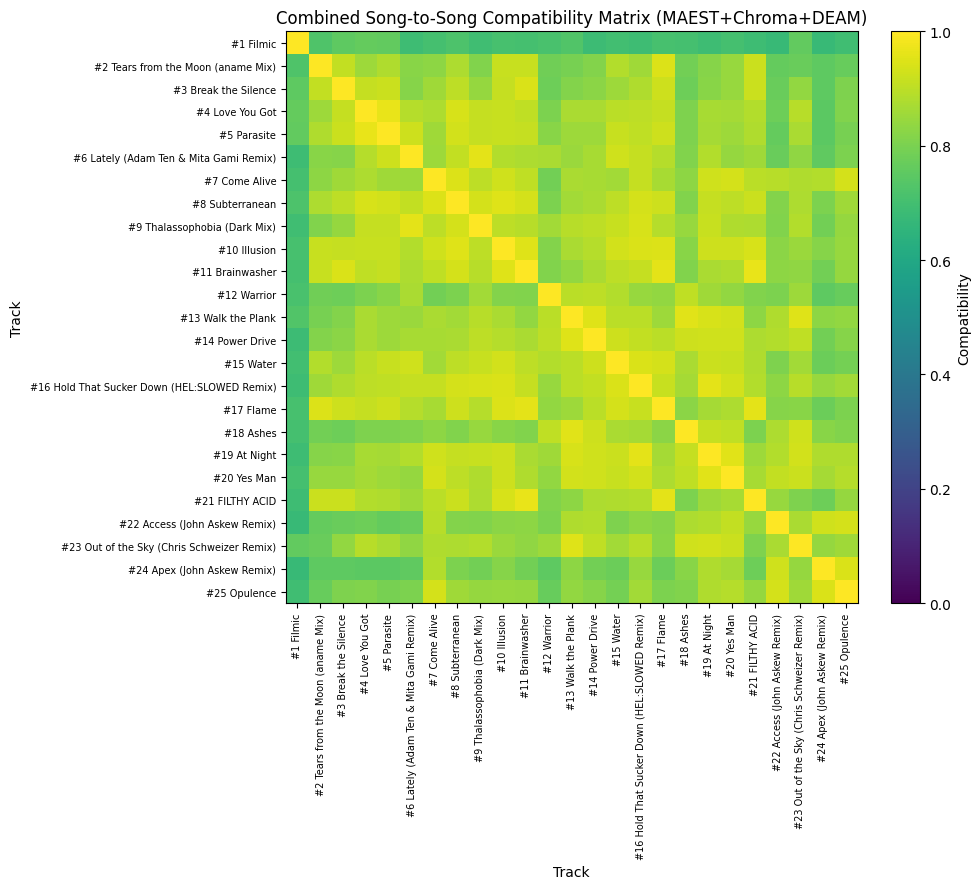

Saved compatibility matrix plot: data/multimodal_compatibility/combined_compatibility_matrix.png
Saved compatibility matrix data: data/multimodal_compatibility/combined_compatibility_matrix.npz


In [7]:
S = combined_similarity_matrix(
    features=features,
    maest_weight=0.5,
    chroma_weight=0.3,
    deam_weight=0.2,
)

labels = [f"#{m.track_number} {m.title}" for m in features.metadata]

fig, ax = plt.subplots(figsize=(11, 9))
im = ax.imshow(S, cmap="viridis", vmin=0.0, vmax=float(np.max(S)))
ax.set_title("Combined Song-to-Song Compatibility Matrix (MAEST+Chroma+DEAM)")
ax.set_xticks(np.arange(len(labels)))
ax.set_yticks(np.arange(len(labels)))
ax.set_xticklabels(labels, rotation=90, fontsize=7)
ax.set_yticklabels(labels, fontsize=7)
ax.set_xlabel("Track")
ax.set_ylabel("Track")
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label="Compatibility")
fig.tight_layout()

matrix_plot = out_dir / "combined_compatibility_matrix.png"
matrix_npz = out_dir / "combined_compatibility_matrix.npz"
fig.savefig(matrix_plot, dpi=220)
plt.show()

np.savez_compressed(matrix_npz, labels=np.array(labels), compatibility=S)

print(f"Saved compatibility matrix plot: {to_project_relpath(matrix_plot)}")
print(f"Saved compatibility matrix data: {to_project_relpath(matrix_npz)}")
